#### prever se as pessoas vao ter um ataque cardiaco do data set da pasta Heart_attack com random forest

In [1]:
# Importar bibliotecas principais: pandas para manipular dataframes,
# seaborn para visualizações e numpy para operações numéricas
import pandas as pd
import seaborn as sns
import numpy as np

# Carrega o dataset do ficheiro CSV para um DataFrame do pandas
df = pd.read_csv(r'../dataset/Heart_Attack/Heart_Attack.csv')

# Mostra as primeiras 10 linhas para inspeção rápida dos dados
df.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,28,Male,atypical angina,130.0,132.0,False,2.0,185.0,no,0.0,NaN,NaN,NaN,0
1,29,Male,atypical angina,120.0,243.0,False,0.0,160.0,no,0.0,NaN,NaN,NaN,0
2,29,Male,atypical angina,140.0,NaN,False,0.0,170.0,no,0.0,NaN,NaN,NaN,0
3,30,Female,typical angina,170.0,237.0,False,1.0,170.0,no,0.0,NaN,NaN,fixed defect,0
4,31,Female,atypical angina,100.0,219.0,False,1.0,150.0,no,0.0,NaN,NaN,NaN,0
5,32,Female,atypical angina,105.0,198.0,False,0.0,165.0,no,0.0,NaN,NaN,NaN,0
6,32,Male,atypical angina,110.0,225.0,False,0.0,184.0,no,0.0,NaN,NaN,NaN,0
7,32,Male,atypical angina,125.0,254.0,False,0.0,155.0,no,0.0,NaN,NaN,NaN,0
8,33,Male,non-anginal pain,120.0,298.0,False,0.0,185.0,no,0.0,NaN,NaN,NaN,0
9,34,Female,atypical angina,130.0,161.0,False,0.0,190.0,no,0.0,NaN,NaN,NaN,0


In [2]:
# Mostra informação geral do DataFrame: número de entradas,
# tipos de cada coluna e contagem de valores não-nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294 entries, 0 to 293
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       294 non-null    int64  
 1   sex       294 non-null    object 
 2   cp        294 non-null    object 
 3   trestbps  293 non-null    float64
 4   chol      271 non-null    float64
 5   fbs       286 non-null    object 
 6   restecg   293 non-null    float64
 7   thalach   293 non-null    float64
 8   exang     293 non-null    object 
 9   oldpeak   294 non-null    float64
 10  slope     104 non-null    object 
 11  ca        3 non-null      float64
 12  thal      28 non-null     object 
 13  num       294 non-null    int64  
dtypes: float64(6), int64(2), object(6)
memory usage: 32.3+ KB


In [3]:
# Mostra estatísticas descritivas (média, desv. padrão, quartis)
# para colunas numéricas — útil para perceber distribuição
df.describe()

,age,trestbps,chol,restecg,thalach,oldpeak,ca,num
count,294.000000,293.000000,271.000000,293.000000,293.000000,294.000000,3.0,294.000000
mean,47.826531,132.583618,250.848708,0.218430,139.129693,0.586054,0.0,0.360544
std,7.811812,17.626568,67.657711,0.460868,23.589749,0.908648,0.0,0.480977
min,28.000000,92.000000,85.000000,0.000000,82.000000,0.000000,0.0,0.000000
25%,42.000000,120.000000,209.000000,0.000000,122.000000,0.000000,0.0,0.000000
50%,49.000000,130.000000,243.000000,0.000000,140.000000,0.000000,0.0,0.000000
75%,54.000000,140.000000,282.500000,0.000000,155.000000,1.000000,0.0,1.000000
max,66.000000,200.000000,603.000000,2.000000,190.000000,5.000000,0.0,1.000000


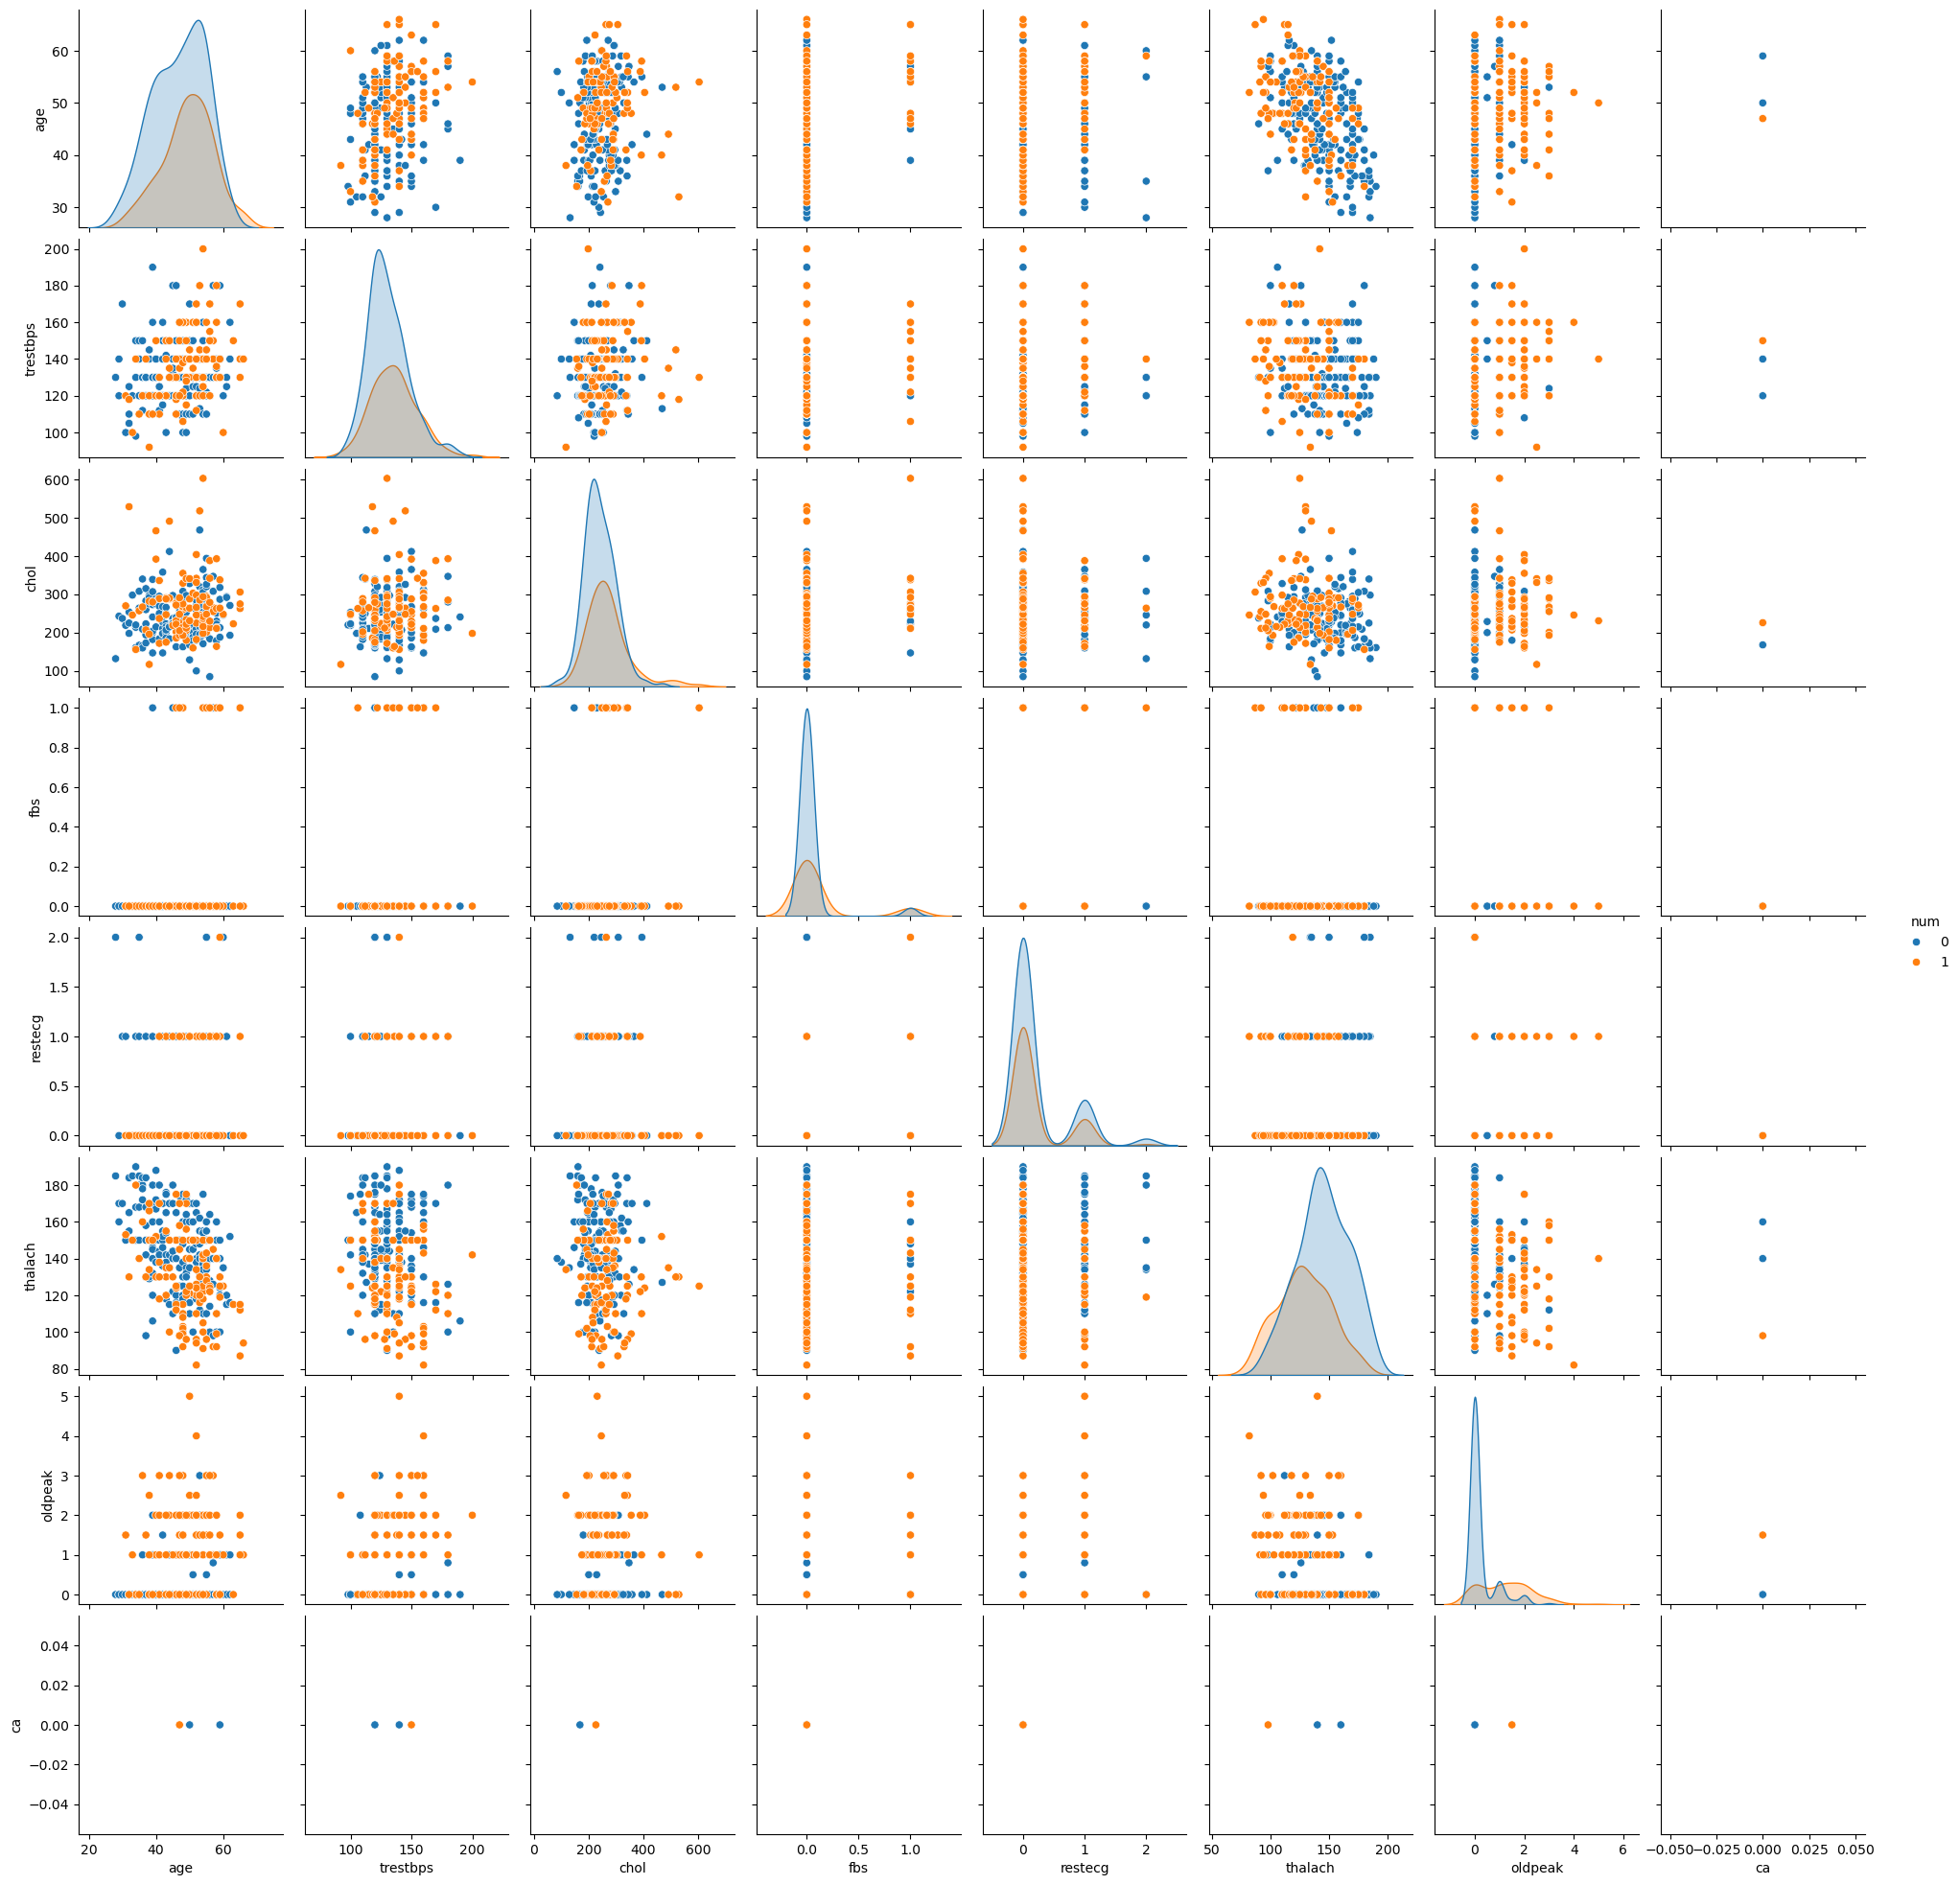

In [4]:
# Pairplot: visualiza relações pairwise entre variáveis
sns.pairplot(df, hue='num')

In [5]:
# Conta valores faltantes (NaN) em cada coluna
df.isnull().sum()

age           0
sex           0
cp            0
trestbps      1
chol         23
fbs           8
restecg       1
thalach       1
exang         1
oldpeak       0
slope       190
ca          291
thal        266
num           0
dtype: int64

In [6]:
# Para cada coluna, conta quantos valores são exatamente 0
# (às vezes 0 é usado para representar ausência de valor)
for col in df.columns:
    print(col + ': ' + str((df[col] == 0).sum()))

age: 0
sex: 0
cp: 0
trestbps: 0
chol: 0
fbs: 266
restecg: 235
thalach: 0
exang: 0
oldpeak: 189
slope: 0
ca: 3
thal: 0
num: 188


In [7]:
# PREPROCESSING: imputação de NaN e codificação de variáveis categóricas em números
# Substitui NaN em 'trestbps' pela mediana da própria coluna (imputação robusta)
df['trestbps'] = df['trestbps'].replace(np.nan, df['trestbps'].median())
# Substitui NaN em 'chol' pela mediana de 'chol'
df['chol'] = df['chol'].replace(np.nan, df['chol'].median())
# Converte 'TRUE'/'FALSE' para 1/0 na coluna 'fbs'
df['fbs'] = df['fbs'].map({'TRUE': 1, 'FALSE': 0})
# Calcula a moda (valor mais frequente) de 'fbs' para usar na imputação
m = df['fbs'].mode()
# Preenche NaN em 'fbs' com a moda; se não houver moda, usa 0 como fallback
df['fbs'] = df['fbs'].fillna(m.iloc[0] if not m.empty else 0)
# Se 'restecg' for numérico, substitui NaN pela mediana
df['restecg'] = df['restecg'].replace(np.nan, df['restecg'].median())
# Substitui NaN em 'thalach' pela mediana
df['thalach'] = df['thalach'].replace(np.nan, df['thalach'].median())
# Converte 'yes'/'no' para 1/0 em 'exang' (exercício com angina)
df['exang'] = df['exang'].map({'yes': 1, 'no': 0})
# Preenche NaN em 'exang' com a moda (valor mais comum)
df['exang'] = df['exang'].fillna(df['exang'].mode().iloc[0])
# Codifica categorias de 'slope' para inteiros
df['slope'] = df['slope'].map({'upsloping': 1, 'flat': 2, 'downsloping': 3})
# Se houver NaN em 'slope', assume 1 (upsloping) como valor por defeito
df['slope'] = df['slope'].replace(np.nan, 1)
# Substitui NaN em 'ca' por -1 para marcar valor desconhecido (atenção ao usar -1)
df['ca'] = df['ca'].replace(np.nan, -1)
# Codifica categorias de 'thal' (tipo de defeito no exame) em inteiros
df['thal'] = df['thal'].map({'normal': 1, 'reversible': 2, 'fixed': 3})
# Preenche NaN em 'thal' com 1 (assumindo 'normal' como padrão)
df['thal'] = df['thal'].replace(np.nan, 1)

In [8]:
# Verifica as primeiras linhas
df.sample(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
78,46,Female,asymptomatic,130.0,238.0,0.0,0.0,90.0,0.0,0.0,1.0,-1.0,1.0,0
215,52,Male,asymptomatic,130.0,225.0,0.0,0.0,120.0,1.0,2.0,2.0,-1.0,1.0,1
220,58,Male,non-anginal pain,130.0,213.0,0.0,1.0,140.0,0.0,0.0,1.0,-1.0,1.0,1
129,52,Male,atypical angina,160.0,196.0,0.0,0.0,165.0,0.0,0.0,1.0,-1.0,1.0,0
40,40,Male,atypical angina,130.0,275.0,0.0,0.0,150.0,0.0,0.0,1.0,-1.0,1.0,0
233,48,Male,asymptomatic,122.0,275.0,0.0,1.0,150.0,1.0,2.0,3.0,-1.0,1.0,1
263,52,Male,asymptomatic,140.0,404.0,0.0,0.0,124.0,1.0,2.0,2.0,-1.0,1.0,1
150,54,Male,atypical angina,120.0,246.0,0.0,0.0,110.0,0.0,0.0,1.0,-1.0,1.0,0
281,44,Male,asymptomatic,135.0,491.0,0.0,0.0,135.0,0.0,0.0,1.0,-1.0,1.0,1
214,51,Female,asymptomatic,160.0,303.0,0.0,0.0,150.0,1.0,1.0,2.0,-1.0,1.0,1


In [ ]:
# One-hot encoding: transforma colunas categóricas em colunas binárias
# Mantém a informação categórica sem impor ordenação (útil para modelos que
# não lidam bem com relações ordinais em categorias nominais)
from sklearn.preprocessing import OneHotEncoder

# Cria o encoder (sparse_output=False retorna matriz densa para criar DataFrame)
encoder = OneHotEncoder(sparse_output=False)
# Colunas que queremos codificar
cols_to_encode = ['cp', 'sex']
# Aplica o encoder e obtém array com as colunas codificadas
encoded_cols = encoder.fit_transform(df[cols_to_encode])
# Converte o resultado para DataFrame, com nomes das novas colunas
encoded_df = pd.DataFrame(encoded_cols, columns=encoder.get_feature_names_out(cols_to_encode))
# Substitui as colunas originais pelas colunas codificadas
df = pd.concat([df.drop(columns=cols_to_encode), encoded_df], axis=1)
# Mostra amostra para verificar a transformação
df.sample(10)

,age,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,cp_asymptomatic,cp_atypical angina,cp_non-anginal pain,cp_typical angina,sex_Female,sex_Male
290,54,130.0,294.0,0.0,1.0,100.0,1.0,0.0,2.0,-1.0,1.0,1,0.0,0.0,1.0,0.0,1.0,0.0
272,56,150.0,230.0,0.0,1.0,124.0,1.0,1.5,2.0,-1.0,1.0,1,1.0,0.0,0.0,0.0,0.0,1.0
104,49,130.0,207.0,0.0,1.0,135.0,0.0,0.0,1.0,-1.0,1.0,0,0.0,0.0,1.0,0.0,1.0,0.0
247,56,150.0,213.0,0.0,0.0,125.0,1.0,1.0,2.0,-1.0,1.0,1,1.0,0.0,0.0,0.0,0.0,1.0
268,55,140.0,295.0,0.0,0.0,136.0,0.0,0.0,1.0,-1.0,1.0,1,0.0,0.0,0.0,1.0,0.0,1.0
150,54,120.0,246.0,0.0,0.0,110.0,0.0,0.0,1.0,-1.0,1.0,0,0.0,1.0,0.0,0.0,0.0,1.0
99,48,140.0,238.0,0.0,0.0,118.0,0.0,0.0,1.0,-1.0,1.0,0,0.0,1.0,0.0,0.0,0.0,1.0
79,46,140.0,275.0,0.0,0.0,165.0,1.0,0.0,1.0,-1.0,1.0,0,0.0,1.0,0.0,0.0,0.0,1.0
111,50,120.0,168.0,0.0,0.0,160.0,0.0,0.0,1.0,0.0,1.0,0,0.0,1.0,0.0,0.0,0.0,1.0
243,54,130.0,603.0,0.0,0.0,125.0,1.0,1.0,2.0,-1.0,1.0,1,1.0,0.0,0.0,0.0,0.0,1.0


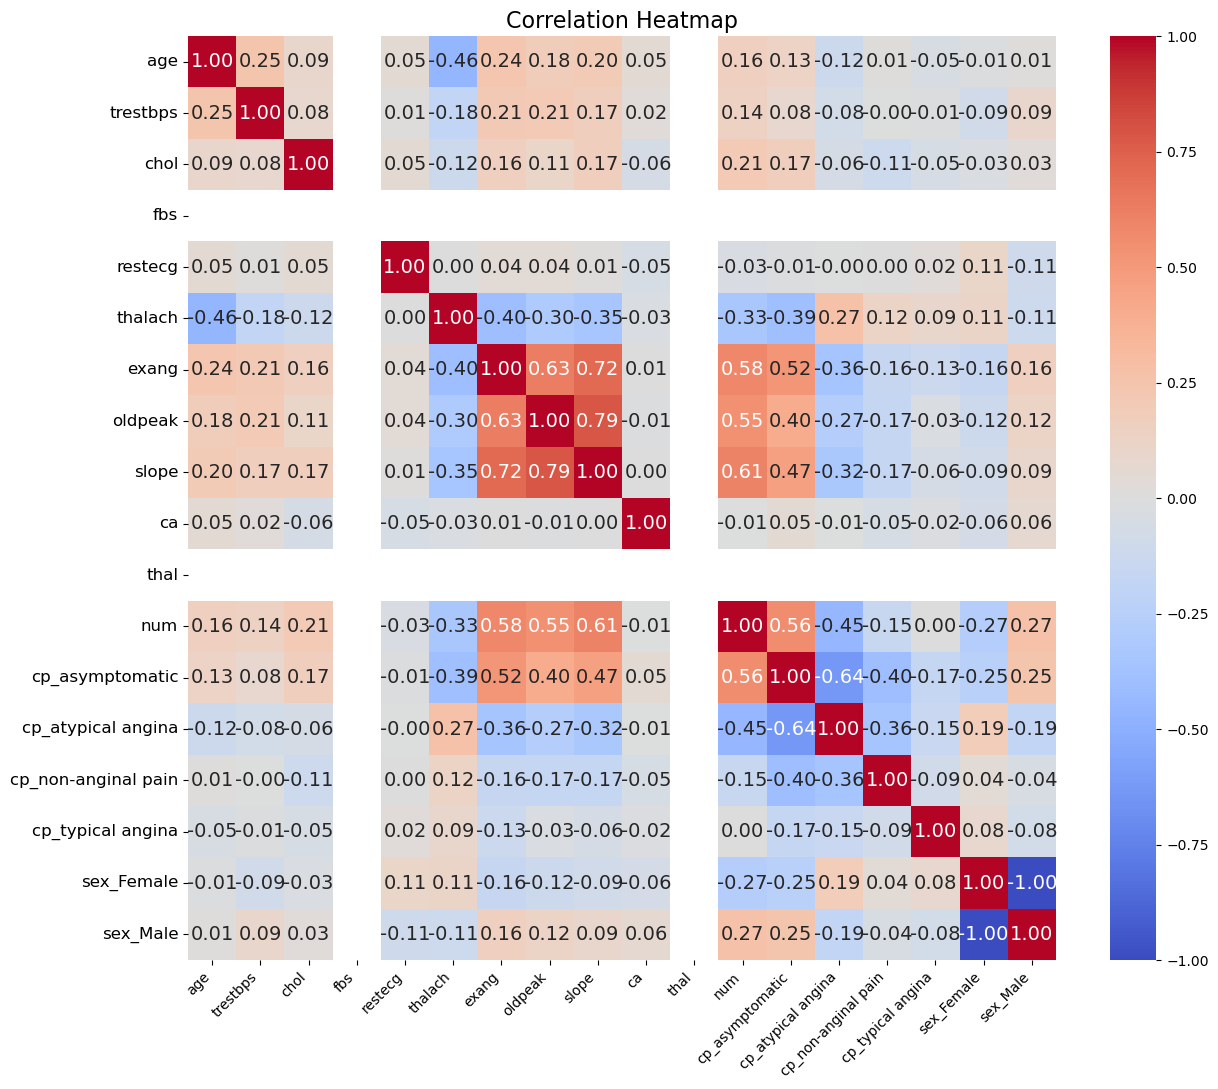

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize = (14, 12))
sns.heatmap(df.corr(), annot=True, fmt=".2f",
             annot_kws={"size": 14},
             cmap='coolwarm')
plt.xticks(rotation = 45, ha = 'right' )
plt.yticks(fontsize = 12)
plt.title('Correlation Heatmap', fontsize = 16)
plt.show()

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294 entries, 0 to 293
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  294 non-null    int64  
 1   trestbps             294 non-null    float64
 2   chol                 294 non-null    float64
 3   fbs                  294 non-null    float64
 4   restecg              294 non-null    float64
 5   thalach              294 non-null    float64
 6   exang                294 non-null    float64
 7   oldpeak              294 non-null    float64
 8   slope                294 non-null    float64
 9   ca                   294 non-null    float64
 10  thal                 294 non-null    float64
 11  num                  294 non-null    int64  
 12  cp_asymptomatic      294 non-null    float64
 13  cp_atypical angina   294 non-null    float64
 14  cp_non-anginal pain  294 non-null    float64
 15  cp_typical angina    294 non-null    flo

In [ ]:
# Treino do modelo Random Forest com pesquisa de hiperparâmetros (GridSearch)
# Importa o classificador e ferramentas de validação/avaliação
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix

# Separa features (X) e label alvo (y)
X = df.drop(columns=['num'])
y = df['num']
# Divide o dataset em treino e teste: 80% treino, 20% teste
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Define os hiperparâmetros a testar no GridSearch
grid_params = {
    'n_estimators': [100, 200, 300],  # número de árvores
    'max_depth': [None, 10, 20],      # profundidade máxima das árvores
    'min_samples_split': [2, 5, 10],  # mínimo de amostras para dividir um nó
    'criterion': ['gini', 'entropy', 'log_loss']  # função de divisão
}

# GridSearchCV testa combinações de parâmetros com validação cruzada (cv=5)
grid = GridSearchCV(estimator=RandomForestClassifier(random_state=42), param_grid=grid_params, cv=5)
# Ajusta o grid ao conjunto de treino — procura a melhor combinação
grid.fit(X_train, Y_train)
# Recupera o melhor estimador encontrado
model = grid.best_estimator_
# Faz predições no conjunto de teste
y_pred = model.predict(X_test)

# Mostra relatório com métricas (precision, recall, f1-score) por classe
print(classification_report(Y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.84      0.85        38
           1       0.73      0.76      0.74        21

    accuracy                           0.81        59
   macro avg       0.80      0.80      0.80        59
weighted avg       0.82      0.81      0.81        59



[[32  6]
 [ 5 16]]
Acuracia: 0.8135593220338984


<Axes: >

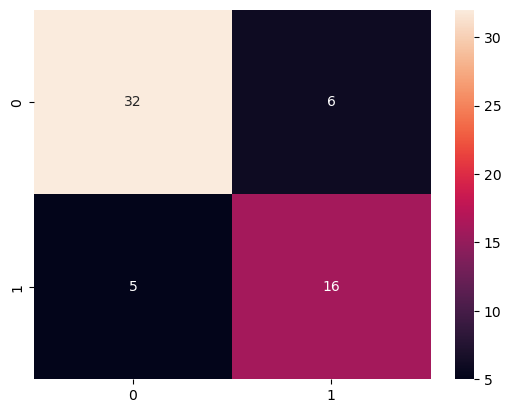

In [ ]:
# Avaliação: matriz de confusão e acurácia
# A matriz mostra TP/FP/FN/TN por classe — útil para entender erros do modelo
print(confusion_matrix(Y_test, y_pred))
# Acurácia global do modelo no conjunto de teste
print("Acuracia:", model.score(X_test, Y_test))
# Visualiza a matriz de confusão com heatmap
sns.heatmap(confusion_matrix(Y_test, y_pred), annot=True, fmt='d')